<a href="https://colab.research.google.com/github/lyntos/Learning/blob/main/Python%20Titanic%20Dataset_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("/content/train.csv")

df


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df["Survived"].unique()

array([0, 1])

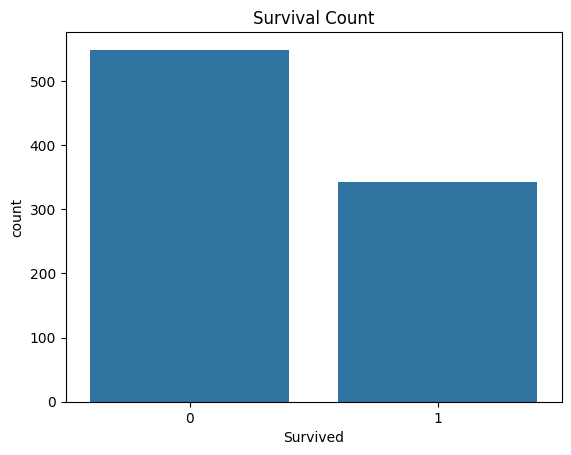

In [ ]:
# 1) we are going to check the count of the survived column by using countplot from seaborn

# In Seaborn, countplot() is a ready-made function:

# 👉 It automatically:

# counts categories
# draws bars
# handles styling

# This is why people use Seaborn for teaching and quick analysis.

ax = sns.countplot(x='Survived', data=df)


plt.title("Survival Count")
plt.show()


👉 Countplot = categorical frequency visualization

👉 Seaborn = easiest tool to create it

“A countplot(ready made function) is not a special type of chart — it’s just a bar chart showing counts of categories. Seaborn gives us a shortcut function to do it easily.”

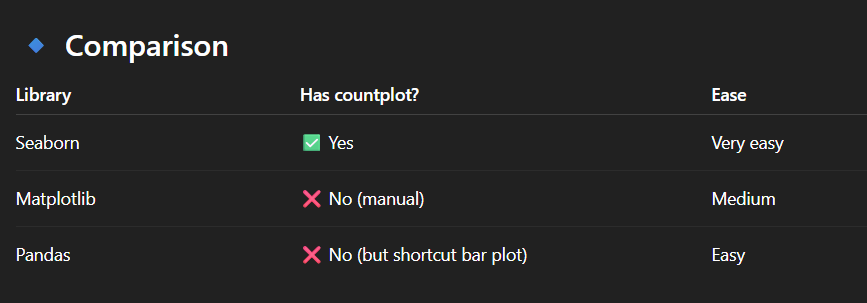

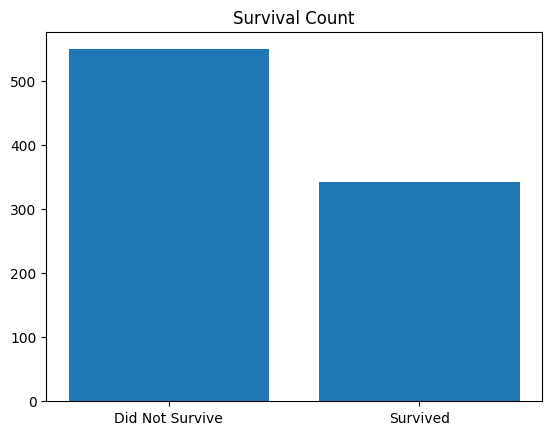

In [ ]:
# 2. In Matplotlib (manual way)

# In Matplotlib, there is no direct countplot function.

# But you can do the same thing manually:

import matplotlib.pyplot as plt

counts = df['Survived'].value_counts()

plt.bar(counts.index, counts.values)
plt.xticks([0, 1], ['Did Not Survive', 'Survived'])
plt.title("Survival Count")
plt.show()

# 👉 Here you:

# first calculate counts
# then plot a bar chart

# plt.bar(counts.index, counts.values)

# 1)👉 counts.index
# These are the categories
# In Titanic:
# 0 = Did not survive
# 1 = Survived

# So:
# counts.index → [0, 1]



# 👉 counts.values
# These are the numbers (frequency)
# counts.values → [549, 342]


# 🔹 So this line means:
# “Draw bars at positions 0 and 1 with heights 549 and 342”

# 🔹 2. plt.xticks([0, 1], ['Did Not Survive', 'Survived'])

# This line is for labeling the x-axis properly.

# 👉 plt.xticks([0, 1], ...)

# This means:

# At position 0, put a label
# At position 1, put a label
# 👉 Labels part:
# ['Did Not Survive', 'Survived']

# So you replace:

# 0 → “Did Not Survive”
# 1 → “Survived”
# 🔹 Why this is needed

# Without this line, your chart would look like:

# 0   1

# That’s not meaningful for students.

# With it:

# Did Not Survive   Survived

# Much clearer 👍

# 🔹 Final idea (simple explanation for class)

# You can say:

# “First we count how many passengers survived and not survived. Then we draw bars for those counts. Finally, we replace numeric labels with human-readable text.”

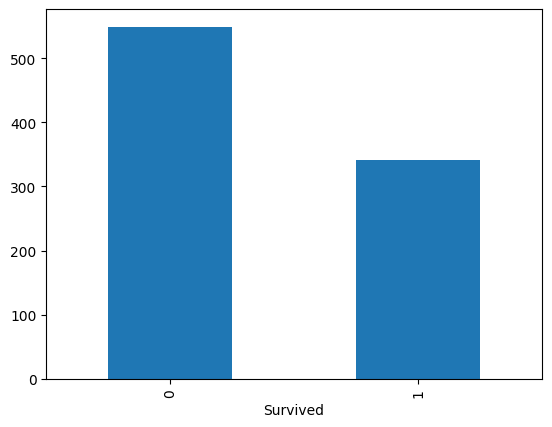

In [ ]:
# 3. In Pandas (shortcut version)

# You can also do it using Pandas directly:

df['Survived'].value_counts().plot(kind='bar')

plt.show()


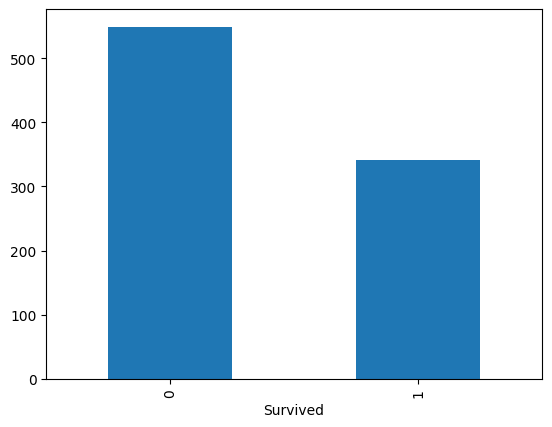

In [ ]:
ax = df['Survived'].value_counts().plot(kind='bar')

# plt.xticks([0, 1], ['Did Not Survive', 'Survived'])
# plt.xlabel("Outcome")
# plt.ylabel("Number of Passengers")
# plt.title("Titanic Survival Count")
# plt.xticks(rotation=0, ha='right')

plt.show()

What rotation=45 means

0 → horizontal labels (default)

45 → tilted diagonally (most common)

90 → vertical labels

plt.xticks(rotation=45, ha='right')

ha='right' aligns text properly

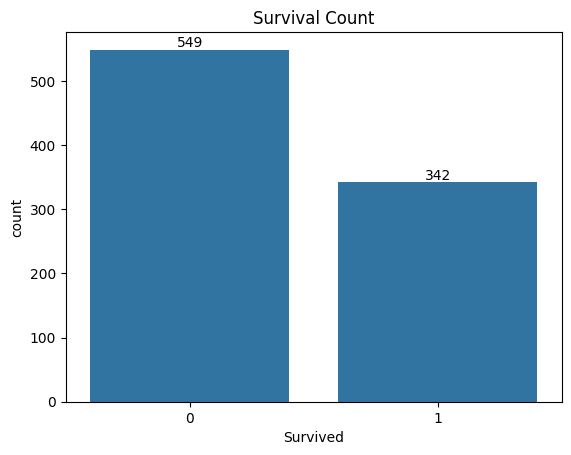

In [ ]:
# to display count on the top of the bar



ax = sns.countplot(x='Survived', data=df)

# Add labels on top of bars

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
               ha='center', va='bottom' )

plt.title("Survival Count")
plt.show()


# 🔍 What this does
# “This code adds labels on top of each bar showing its exact value. It calculates the bar height and places the text at the center-top position.”

# ax.patches → gives each bar

# 1. f'{int(p.get_height())}'-->

                # p is a single bar in the chart (usually from a loop over bars).

                # 👉 p.get_height()
                # gives the height of the bar
                # i.e., the value/count

                # Example:

                # Bar height = 342
                # 👉 int(...)

                # Converts it to a clean integer (removes decimals if any)

                # 👉 f''

                # Formats it as text

                # ✔ So this part means:

                # “Write the number on the bar (like 342)”

# p.get_height()	-->value of bar

# get_x() + p.get_width() / 2	-->center of bar

# p.get_x() -->left edge of the bar || p.get_width() / 2--> moves to the center of the bar
          # so, x-position = middle of bar

# p.get_height() value of the bar
          # so, y-position = top of the bar

# annotate()	-->place text
# ha='center'	-->center align text
# va='bottom'-->	place text above bar
# annotate() → places the number above the bar

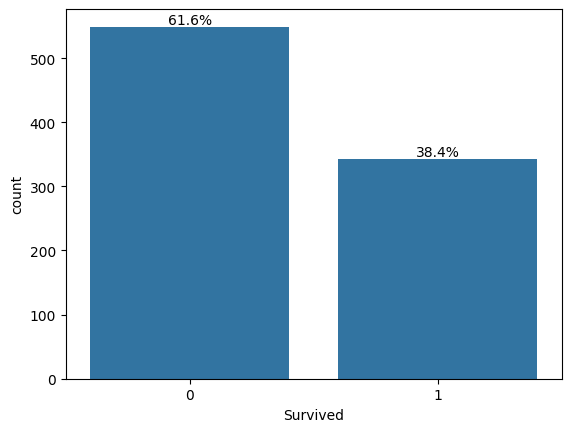

In [ ]:
# Show percentages instead of counts:
ax = sns.countplot(x='Survived', data=df)

# Add labels on top of bars


for p in ax.patches:
    percentage = 100 * p.get_height() / total
    ax.annotate(f'{percentage:.1f}%',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')

pie chart

You can create a pie chart for survival proportion pretty easily using either Matplotlib or Pandas.

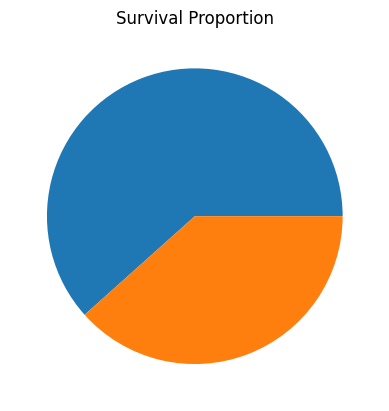

In [ ]:
import matplotlib.pyplot as plt

counts = df['Survived'].value_counts()


plt.pie(counts)
plt.title("Survival Proportion")
plt.show()

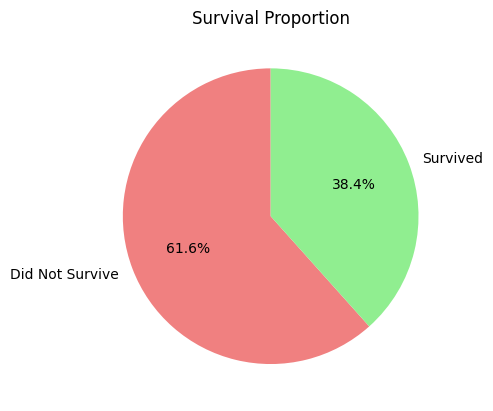

In [ ]:
# Using Matplotlib (more control)
import matplotlib.pyplot as plt

counts = df['Survived'].value_counts()


plt.pie(
    counts,
    labels=['Did Not Survive', 'Survived'],
    autopct='%1.1f%%',
    colors=['lightcoral', 'lightgreen'],
    startangle=90
)

plt.title("Survival Proportion")
plt.show()

# A Grouped Bar Chart (for Pclass vs Survived)

pclass-passenger class


This helps you compare survival across passenger classes (1st, 2nd, 3rd class)
side by side.

This is one of the most powerful insights in the Titanic dataset.

🔹 What we are trying to understand from this dataset is



    “Did passenger class affect survival?”


    (we want to answer for this question)

So we compare:

      Pclass = 1, 2, 3

      against Survived = 0 or 1

In [ ]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [ ]:
df['Pclass'].unique()

array([3, 1, 2])

In [ ]:
# Step 1: Create the data

# We first group the data:

import pandas as pd

survival_by_class = pd.crosstab(df['Pclass'], df['Survived'])
print(survival_by_class)


# 🔹 Output looks like:

# Survived    0    1

# Pclass
# 1           80   136
# 2           97   87
# 3           372  119

# 👉 This means:

# 1st class had more survivors
# 3rd class had many more deaths

Survived    0    1
Pclass            
1          80  136
2          97   87
3         372  119


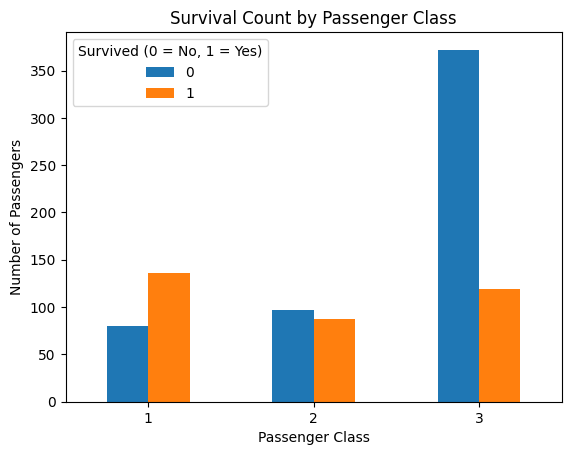

In [ ]:
# Step 2: Plot Grouped Bar Chart

# Now we plot it using Matplotlib:

import matplotlib.pyplot as plt

survival_by_class.plot(kind='bar')

plt.title("Survival Count by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.xticks(rotation=0)

plt.legend(title="Survived (0 = No, 1 = Yes)")
plt.show()
# 🔹 What this chart shows

# Each class has two bars side-by-side:

# For each Pclass:

# One bar = Did NOT survive (0)
# One bar = Survived (1)

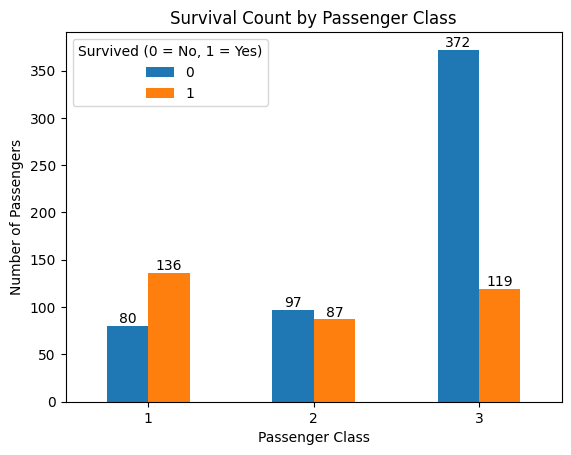

In [ ]:
# to see value inside the bar



import matplotlib.pyplot as plt

# ax =survival_by_class.plot(kind='bar')




# for p in ax.patches:
#     ax.annotate(
#         f'{int(p.get_height())}',
#         (p.get_x() + p.get_width() / 2, p.get_height()),
#         ha='center',
#         va='bottom'
#     )

plt.title("Survival Count by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.xticks(rotation=0)

plt.legend(title="Survived (0 = No, 1 = Yes)")
plt.show()

# stacked bar chart

A stacked bar chart shows how each category is split into parts inside the same bar.

For Titanic:

Each passenger class (Pclass) will show how many survived vs did not survive inside the same bar.

In [ ]:
# Step 1: Prepare the data

# We first create a summary table using Pandas:

import pandas as pd

stack_data = pd.crosstab(df['Pclass'], df['Survived'])
print(stack_data)

# 🔹 Output example:
# Survived    0    1
# Pclass
# 1           80  136
# 2           97   87
# 3          372  119

Survived    0    1
Pclass            
1          80  136
2          97   87
3         372  119


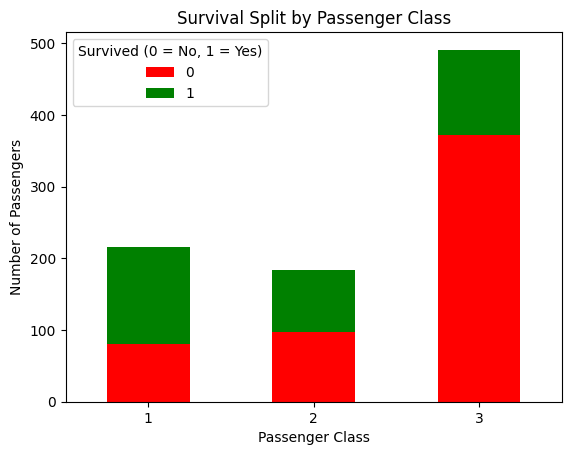

In [ ]:
# Step 2: Create Stacked Bar Chart

# Now plot it using Matplotlib:

import matplotlib.pyplot as plt

stack_data.plot(
    kind='bar',
    stacked=True,
    color=['red', 'green']
)

plt.title("Survival Split by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.xticks(rotation=0)

plt.legend(title="Survived (0 = No, 1 = Yes)")
plt.show()

# 🔹 What “stacked” means

# Instead of side-by-side bars:

        # ❌ Grouped bar:

        # Pclass 1 → [Died] [Survived]


# ✅ Stacked bar:

      # Pclass 1 → [Died stacked on Survived]

      # So each bar = total passengers in that class


# “Each bar represents a passenger class. The bar is divided into survivors and non-survivors, showing both total size and composition at the same time.”


# Key insights students learn

# 💡 1. Total vs composition

    # Height of bar = total passengers in class
    # Colors show survival split

# 💡 2. Class impact becomes clearer
        # 3rd class has:
           # large red (death portion)
# 1st class has:
        # larger green (survival portion)




# 👉 Stacked bar chart = composition inside each category
# 👉 Titanic insight = class strongly affects survival

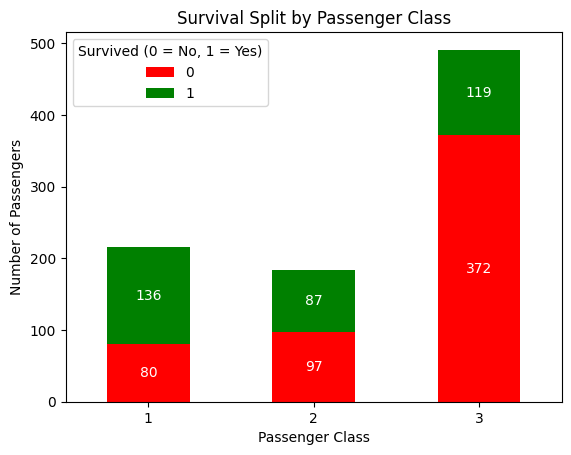

In [ ]:
# add value inside the bar

import matplotlib.pyplot as plt

ax=stack_data.plot(
    kind='bar',
    stacked=True,
    color=['red', 'green']
)

# for container in ax.containers:
#     ax.bar_label(container, label_type='center', color='white')

plt.title("Survival Split by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.xticks(rotation=0)

plt.legend(title="Survived (0 = No, 1 = Yes)")
plt.show()


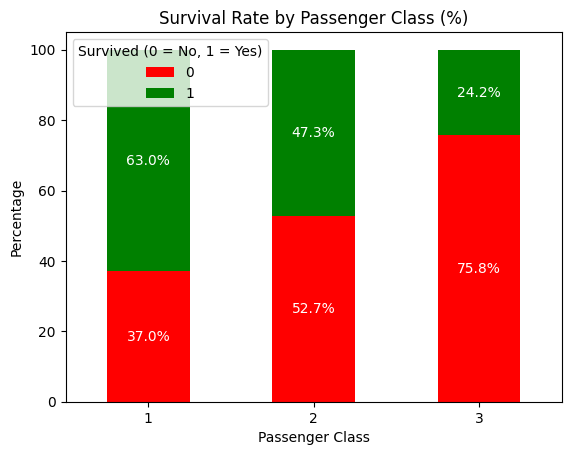

In [ ]:
# Step 3: Add percentage labels inside bars

import pandas as pd
import matplotlib.pyplot as plt

stack_data = pd.crosstab(df['Pclass'], df['Survived'])

# stack_percent = stack_data.div(stack_data.sum(axis=1), axis=0) * 100

ax = stack_percent.plot(
    kind='bar',
    stacked=True,
    color=['red', 'green']
)

plt.title("Survival Rate by Passenger Class (%)")
plt.xlabel("Passenger Class")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Survived (0 = No, 1 = Yes)")

# for container in ax.containers:
#     ax.bar_label(container, fmt='%.1f%%', label_type='center', color='white')

plt.show()


# axis=0 → column-wise operations
# axis=1 → row-wise operations

# count plot with hue

A count plot with hue is one of the most useful visualizations for the Titanic dataset because it shows:

“How many males vs females survived and did not survive”

What is hue?

In Seaborn:

x = main category

hue = sub-category (split inside each bar)

So:

You are splitting each bar into colored groups

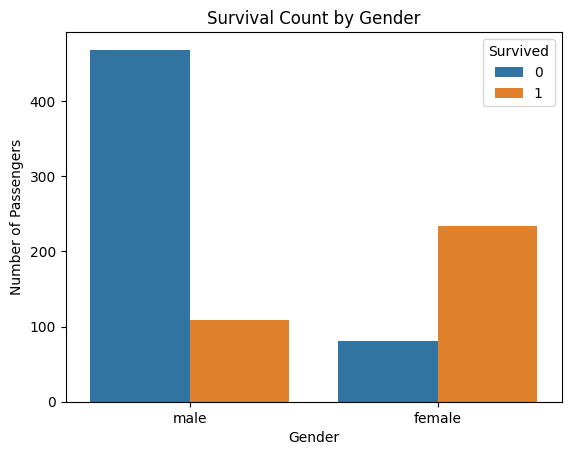

In [ ]:
# 🔹 Code: Sex + Survived count plot
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Sex', hue='Survived', data=df)

plt.title("Survival Count by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

plt.show()

# What this chart shows

# You get two bars (Male, Female) and each bar is split into:

# 🔴 Survived = 0 (did not survive)
# 🟢 Survived = 1 (survived)

How to read it

👨 Male bar:

    large portion = did NOT survive

    small portion = survived

👩 Female bar:

    larger portion = survived

    smaller portion = did NOT survive

🔹 Key insight students learn

    survival was strongly affected by gender

You can explain:

    “Females had a much higher survival rate compared to males, which reflects the ‘women and children first’ policy during evacuation.”

Why hue is powerful

Without hue:

    you only see total males vs females

With hue:

    you see breakdown inside each group

👉 It turns simple counting into insight discovery

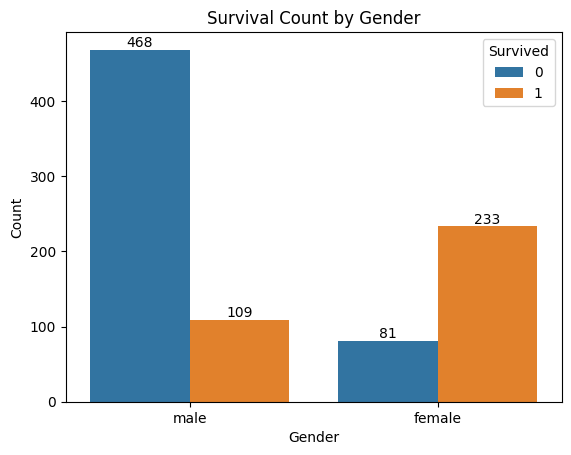

In [ ]:
# add values on top of each bar
import seaborn as sns
import matplotlib.pyplot as plt

ax = sns.countplot(x='Sex', hue='Survived', data=df)

plt.title("Survival Count by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")

for container in ax.containers:
    ax.bar_label(container)

plt.show()


# heatmap

A heatmap from a pivot table is one of the best ways to show relationships in the Titanic dataset.

Here you are trying to answer:

    “How does survival change based on Sex and Passenger Class?”

In [ ]:
# Step 1: Create a pivot table

# We use Pandas to compute survival rate:

import pandas as pd

pivot = pd.pivot_table(
    df,
    values='Survived',
    index='Sex',
    columns='Pclass',
    aggfunc='mean'
)
pivot



# What this does
# values='Survived' → we analyze survival

# index='Sex' → rows = male, female
# columns='Pclass' → columns = 1st, 2nd, 3rd class
# aggfunc='mean' → gives survival rate (0 to 1)

Pclass,1,2,3
Sex,,,
female,0.968085,0.921053,0.500000
male,0.368852,0.157407,0.135447


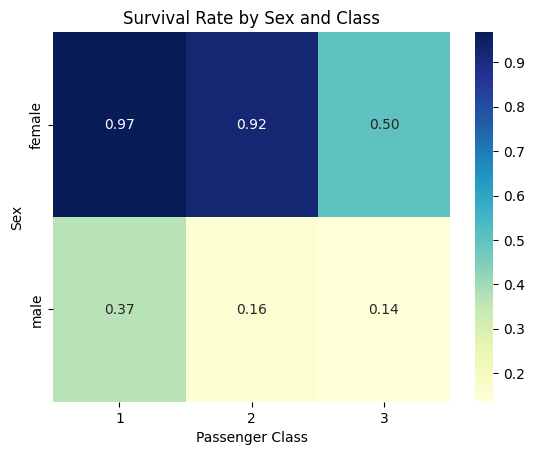

In [ ]:
# Step 2: Create heatmap

# Now visualize using Seaborn:

import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(pivot, annot=True, cmap='YlGnBu', fmt=".2f")#'coolwarm'

plt.title("Survival Rate by Sex and Class")
plt.xlabel("Passenger Class")
plt.ylabel("Sex")

plt.show()


# What the heatmap shows
# 🎨 Colors:
# Darker / greener → higher survival rate
# Lighter → lower survival rate
# 📊 Values:
# annot=True → shows numbers inside cells


# “This heatmap shows survival rates for each combination of gender and class. Darker colors mean higher survival chances.”

# 3. Age & Fare Distributions

Now move into numerical data.

    •	Histogram of Age

    •	Histogram of Fare

    •	KDE plot (distribution curve)

    •	Boxplot

          → Age vs Survived

          → Fare vs Survived

    •	Violin plot
    
          → more advanced version of boxplot

👉 Teaches: distributions + spread + outliers


# Histogram

A histogram of Age shows the distribution of passenger ages in the Titanic
dataset — basically how passengers are spread across different age groups.


This is one of the most important first steps in numerical data analysis.

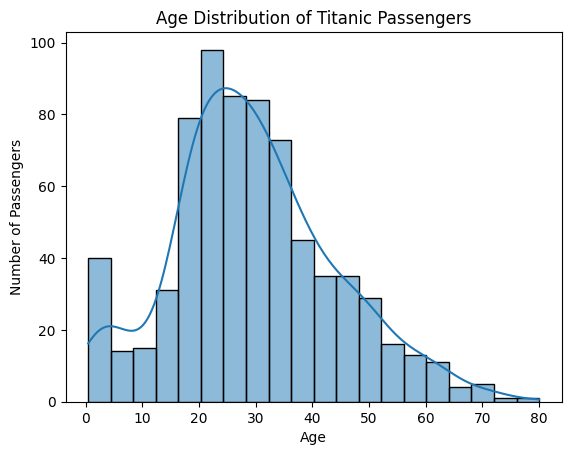

In [ ]:
# Code (Age Histogram)

# We’ll use Seaborn or Matplotlib.

# ✅ Option 1: Seaborn (clean and easy)
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['Age'], bins=20, kde=True)

# What does kde=True do?

# In Seaborn:

# Adds a smooth curve over histogram
# Shows overall trend of age distribution

plt.title("Age Distribution of Titanic Passengers")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()


# What is a histogram?

# A histogram shows:

# “How many people fall into each age range”

# Example:

    # 0–10 years → children count
    # 20–30 years → young adults
    # 30–40 years → adults

Key insights from Titanic Age histogram

💡 1. Most passengers are adults

Peak usually around 20–40 years

💡 2. Some children are present

Smaller bars at low ages

💡 3. Missing values issue

Titanic has missing ages → gaps may exist

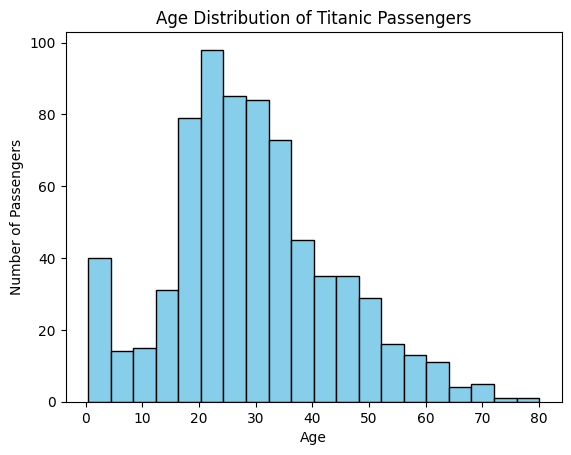

In [ ]:
# ✅ Option 2: Matplotlib
plt.hist(df['Age'], bins=20, color='skyblue', edgecolor='black')

plt.title("Age Distribution of Titanic Passengers")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

A Histogram of Fare shows how ticket prices are distributed in the Titanic dataset — i.e., how many passengers paid low, medium, or high fares.

This is important because Titanic fares are usually highly skewed (a few people paid very expensive tickets).

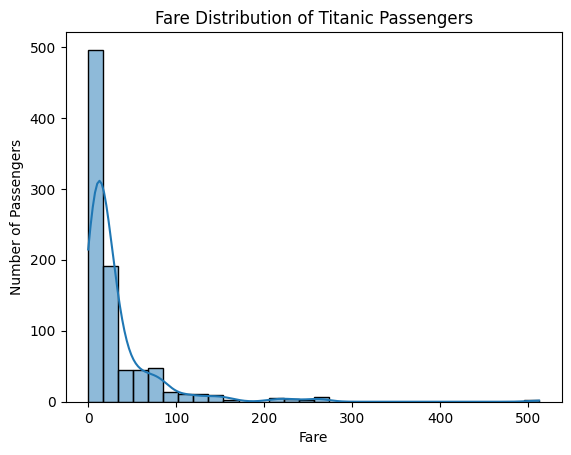

In [ ]:
# Code (Fare Histogram)

# We’ll use Seaborn or Matplotlib.

# ✅ Option 1: Seaborn (recommended)
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['Fare'], bins=30, kde=True)

plt.title("Fare Distribution of Titanic Passengers")
plt.xlabel("Fare")
plt.ylabel("Number of Passengers")

plt.show()

What this histogram shows

It groups passengers based on ticket price:

Low fare → most passengers

Medium fare → fewer passengers

High fare → very few passengers

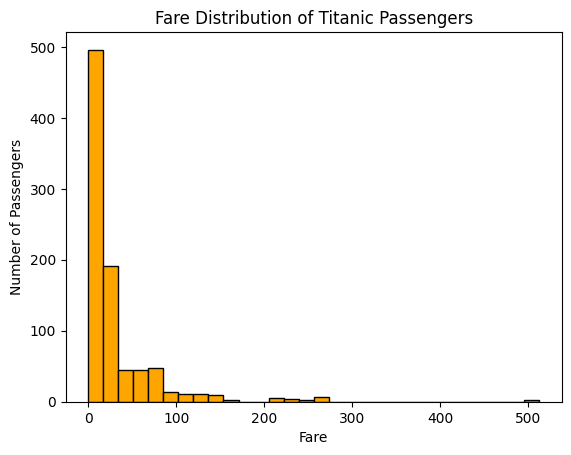

In [ ]:
# Option 2: Matplotlib
plt.hist(df['Fare'], bins=30, color='orange', edgecolor='black')

plt.title("Fare Distribution of Titanic Passengers")
plt.xlabel("Fare")
plt.ylabel("Number of Passengers")

plt.show()

In [ ]:
# Key insight (VERY IMPORTANT)
# 💡 1. Highly skewed data

# Most Titanic passengers paid:

        # very low fares

# But a few paid:

      # extremely high fares

# 💡 2. Wealth inequality pattern

# This reflects social structure:

      # 3rd class → cheap tickets
      # 1st class → expensive tickets

# 💡 3. Outliers exist

      # Some fares are extremely large → stretch the graph to the right

# 🔹 Why this matters in teaching

# You can explain:

# “Unlike age, fare is not evenly distributed. A few wealthy passengers paid very high prices, creating a skewed distribution.”

# KDE Plot

A KDE plot (Kernel Density Estimate) shows a smooth curve of a distribution instead of bars like a histogram.

It helps you understand the shape of the data (where values are concentrated, peaks, spread).

We’ll use Seaborn.

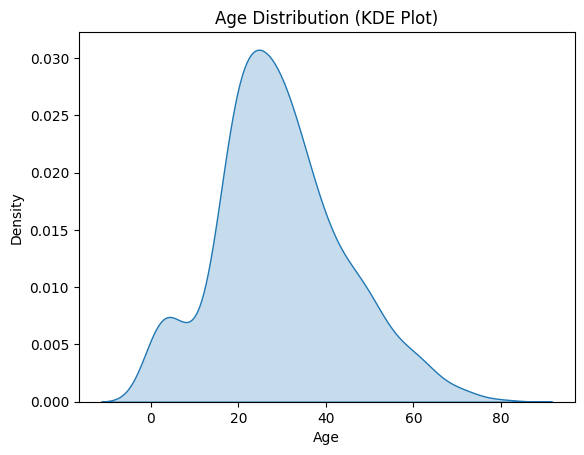

In [ ]:
# KDE Plot of Age
import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(df['Age'], fill=True)

plt.title("Age Distribution (KDE Plot)")
plt.xlabel("Age")
plt.ylabel("Density")

plt.show()

# Titanic insights (Age KDE)
# Peak around 20–40 years
# Few children and elderly
# Most passengers are adults

What is KDE?

A KDE plot shows:

“Where data is most concentrated, in a smooth curve form”

Instead of counting bins like a histogram, it:

places a small “bell curve” on each data point

adds them together

creates a smooth line

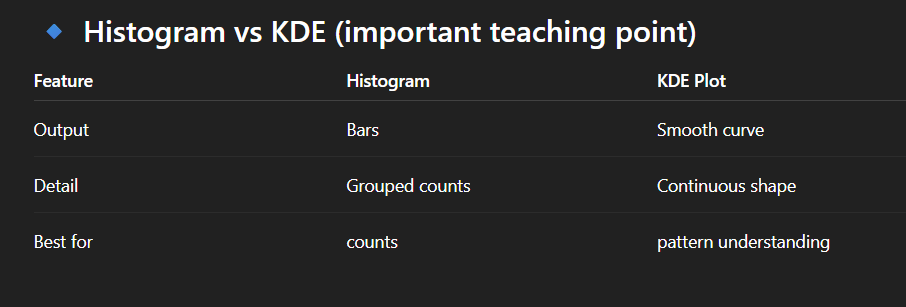

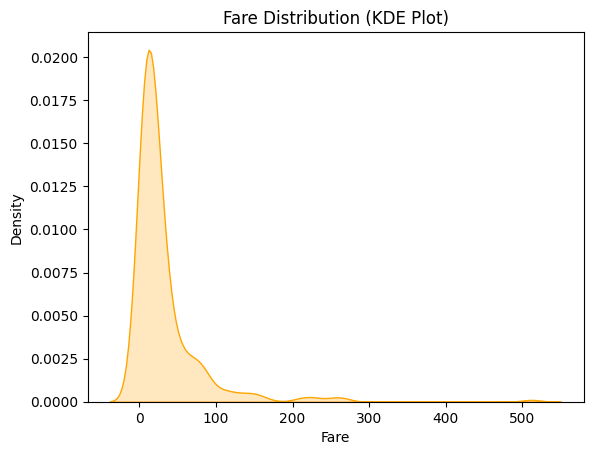

In [ ]:
# 🔹 KDE Plot of Fare
sns.kdeplot(df['Fare'], fill=True, color='orange')

plt.title("Fare Distribution (KDE Plot)")
plt.xlabel("Fare")
plt.ylabel("Density")

plt.show()


# Titanic insights (Fare KDE)
# Strong right skew
# Most fares are low
# Few extremely high fares

<Axes: xlabel='Age', ylabel='Count'>

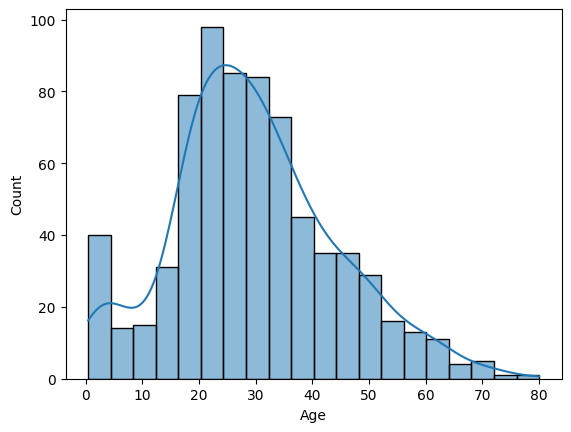

In [ ]:
# Optional improvement (combine with histogram)

sns.histplot(df['Age'], bins=20, kde=True)

# 👉 This shows both:

# bars (counts)
# curve (distribution shape)
# 🔹 Final takeaway
# KDE = smooth distribution curve
# Shows pattern, not counts
# Helps understand shape of data

A boxplot is used to compare the distribution of a numerical variable across categories.

In your Titanic dataset, we use it to understand:

How Age and Fare differ between passengers who survived and those who did not.

We’ll use Seaborn.

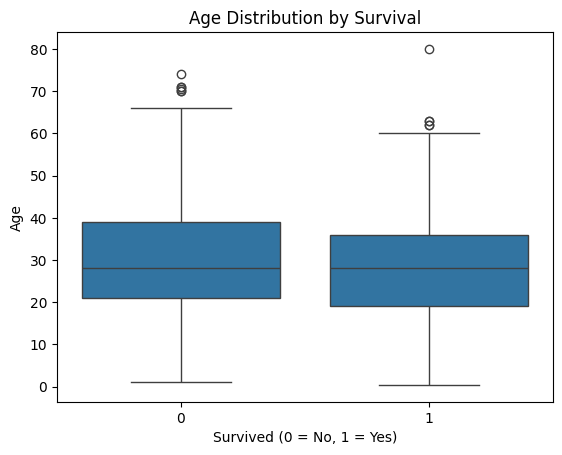

In [ ]:
# 🔹 1. Boxplot: Age vs Survived
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='Survived', y='Age', data=df)

plt.title("Age Distribution by Survival")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Age")

plt.show()
# 🔹 What this shows

# For each group (0 and 1), you see:

# Median age (middle line)
# Spread of ages (box size)
# Outliers (dots)
# 🔹 Insight (Age vs Survival)
# Children had slightly higher survival chances
# Adults dominate both groups
# Some older passengers appear as outliers

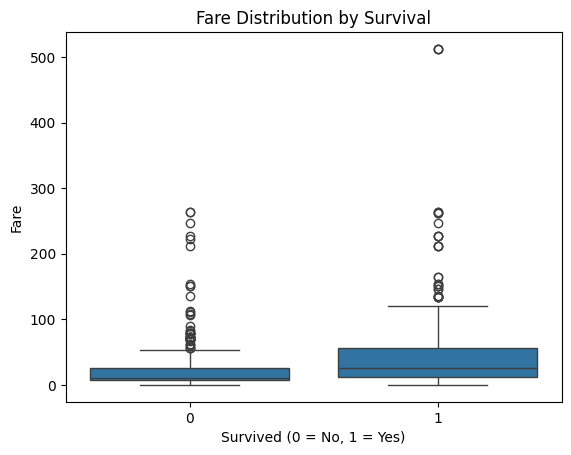

In [ ]:
# 2. Boxplot: Fare vs Survived
sns.boxplot(x='Survived', y='Fare', data=df)

plt.title("Fare Distribution by Survival")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Fare")

plt.show()

In [ ]:
# 🔹 What this shows

#     Survival group (1) often has higher fare values
#     Non-survivors mostly paid lower fares
#     Many extreme outliers in Fare


# 🔹 Insight (Fare vs Survival)

# 👉 Important pattern:

#     Higher fare → higher survival chance
#     Lower fare → lower survival chance

# This reflects social class impact



# 🔹 What is a boxplot?

# A boxplot shows 5 key things:

# 📦 1. Median
# Middle line in the box

# 📦 2. Q1 and Q3
# Bottom and top of box (middle 50%)

# 📦 3. IQR (spread)
# Height of box

# 📦 4. Whiskers
# Normal range of data

# 📦 5. Outliers
# Dots outside whiskers

🔹 Key takeaway

Age vs Survival:

    Similar age distribution in both groups

    Slight advantage for younger passengers

Fare vs Survival:

    Survivors generally paid higher fares

    Strong link between wealth and survival

🔹 Final insight for students

“Boxplots show that survival was influenced more by fare (wealth/class) than age alone.”

A violin plot is a more detailed version of a boxplot. It shows not only summary statistics but also the full shape of the distribution.

We’ll use Seaborn.

# 🔹 What is a violin plot?

A violin plot combines:

📦 Boxplot (median, quartiles)

🎻 KDE plot (distribution shape)

So instead of just showing summary, it shows:

“How the data is distributed + where it is concentrated”

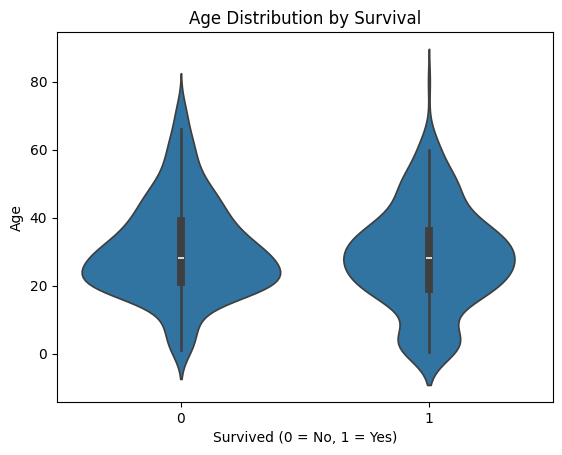

In [ ]:
# 🔹 1. Age vs Survived (Violin Plot)
import seaborn as sns
import matplotlib.pyplot as plt

sns.violinplot(x='Survived', y='Age', data=df)

plt.title("Age Distribution by Survival")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Age")

plt.show()


# 🔹 What this shows

# For each survival group:

# Thick area = more passengers at that age
# Thin area = fewer passengers
# White dot = median
# Thick bar = interquartile range

In [ ]:
# 🔹 2. Fare vs Survived (Violin Plot)

sns.violinplot(x='Survived', y='Fare', data=df)

plt.title("Fare Distribution by Survival")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Fare")

plt.show()


# 🔹 What this shows
# Survivors (1) often have a wider spread in Fare
# Non-survivors (0) are concentrated in low fares
# Long tail shows rich passengers (outliers)

🔹 Key insight from Titanic data

💡 Age vs Survival

    Similar age distributions

    Slight density shift for younger survivors

💡 Fare vs Survival

    Strong difference in shape

    Survivors skew toward higher fares

👉 This confirms:

    Wealth/class had a stronger impact than age

🔹 How to explain in class (simple)

You can say:

“A violin plot shows both summary statistics and the full distribution shape, helping us see where data is concentrated.”

🔹 Simple intuition for students

Boxplot = summary of data

Violin plot = summary + shape of data

Violin plot helps you see:

distribution shape

density of data

group comparisons

# 4. Family & Social Factors

Interesting storytelling section.

•	Bar chart

    → SibSp vs survival rate

•	Bar chart

    → Parch vs survival

•	Create new feature: Family Size

      df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

•	Then:

    → FamilySize vs Survival

👉 Students LOVE this part because it feels like discovering something.


That’s a great storytelling angle—SibSp (siblings/spouses aboard) often reveals interesting social dynamics.

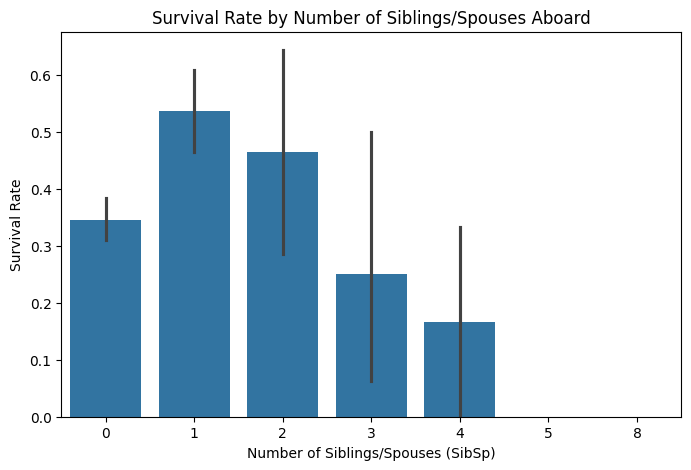

In [ ]:
# Bar Chart: SibSp vs Survival Rate

# This shows how survival probability changes depending on how many close relatives a passenger had onboard.

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.barplot(x='SibSp', y='Survived', data=df)

plt.title('Survival Rate by Number of Siblings/Spouses Aboard')
plt.xlabel('Number of Siblings/Spouses (SibSp)')
plt.ylabel('Survival Rate')

plt.show()

How to Explain This to Students

Instead of just showing the chart, guide them with questions:

Do passengers traveling alone survive more or less?

What happens as family size increases?

Is there a “sweet spot” (e.g., small families)?

💡 Typical Insight (what they’ll likely see)

    SibSp = 0 → moderate survival

    SibSp = 1–2 → often higher survival

    SibSp ≥ 3–4 → survival drops significantly

👉 Interpretation:

Small families may have helped each other

Large groups may have struggled to coordinate or access lifeboats

<Axes: xlabel='SibSp', ylabel='Survived'>

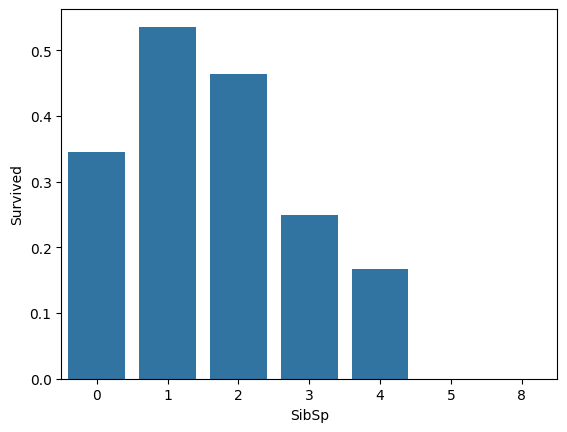

In [ ]:
# 🔄 Make It Even Better (Cleaner Aggregation)

# To make the logic explicit (good for teaching):

sibsp_survival = df.groupby('SibSp')['Survived'].mean().reset_index()

sns.barplot(x='SibSp', y='Survived', data=sibsp_survival)

In [ ]:
# Optional Upgrade: Combine Family Size

# You can connect this with a richer concept:

df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# Then compare:

# Alone
# Small family
# Large family

Parch stands for “Parents/Children aboard” on the Titanic.

It tells you how many parents or children a passenger was traveling with.

📌 Examples

Parch = 0 → traveling alone (no parents or kids)

Parch = 1 → with either one parent or one child

Parch = 2 → could be:two children/one parent + one child

Parch = 3+ → larger family group

In [ ]:
df['FamilySize']

,FamilySize
0,2
1,2
2,1
3,2
4,1
...,...
886,1
887,1
888,4
889,1


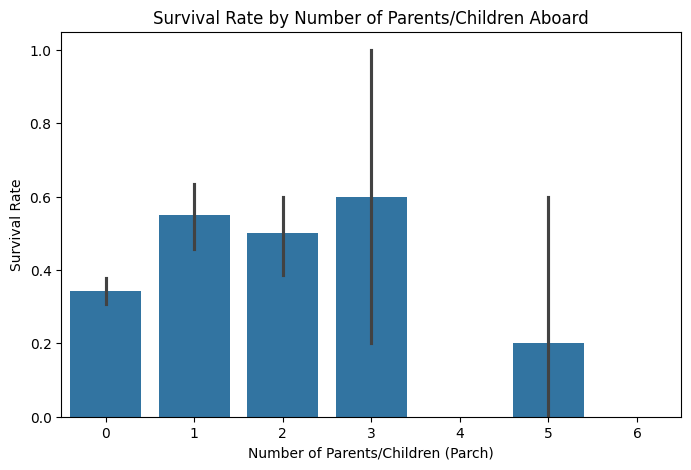

In [ ]:
# 📊 Bar Chart: Parch vs Survival Rate
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.barplot(x='Parch', y='Survived', data=df)

plt.title('Survival Rate by Number of Parents/Children Aboard')
plt.xlabel('Number of Parents/Children (Parch)')
plt.ylabel('Survival Rate')

plt.show()

# 🔹 5. Embarkation Insights

•	Count plot

    → Embarked vs Survived

•	Stacked bar

    → Port vs survival
    
👉 Good for showing geographic/social differences


This is a great section—Embarked adds a subtle but powerful “geography + class + access” story.

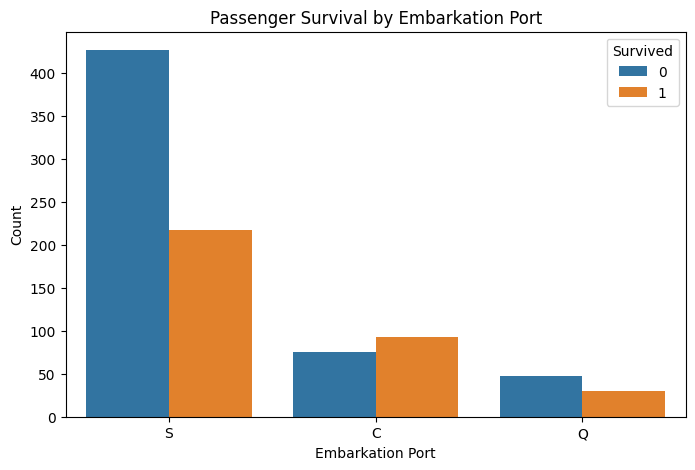

In [ ]:
# 1. Count Plot: Embarked vs Survived

# This shows raw counts (how many survived vs not from each port).

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.countplot(x='Embarked', hue='Survived', data=df)

plt.title('Passenger Survival by Embarkation Port')
plt.xlabel('Embarkation Port')
plt.ylabel('Count')

plt.show()

# 🔍 How to Explain
# Each bar = a port (C, Q, S)
# Colors = survived vs not survived
# Helps students see absolute numbers

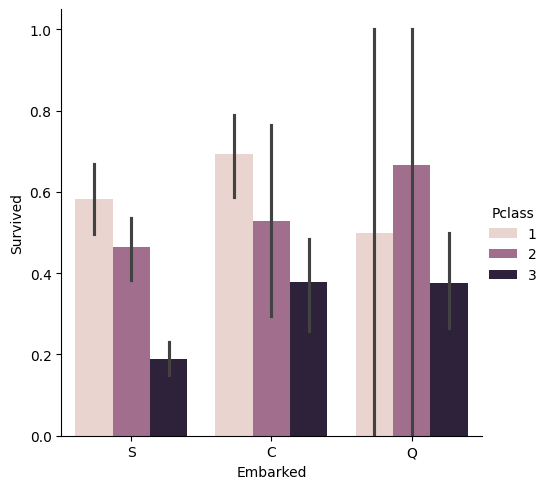

In [ ]:
# Pro Upgrade (Powerful Visual)

# Combine with class:

sns.catplot(x='Embarked', y='Survived', hue='Pclass', kind='bar', data=df)

# 👉 This reveals the real driver behind the pattern.

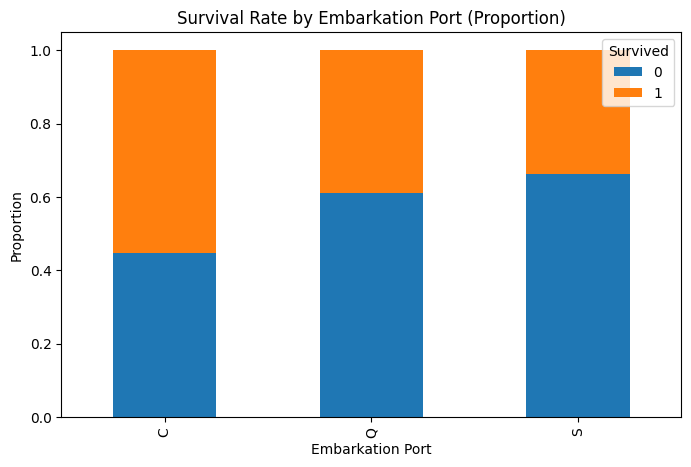

In [ ]:
# Even Better: Normalize (Percentages)

# This avoids misleading interpretations due to different group sizes:

port_survival_norm = df.groupby('Embarked')['Survived'].value_counts(normalize=True).unstack()

port_survival_norm.plot(kind='bar', stacked=True, figsize=(8,5))

plt.title('Survival Rate by Embarkation Port (Proportion)')
plt.xlabel('Embarkation Port')
plt.ylabel('Proportion')

plt.show()

Port Meanings (Important for Students)

C = Cherbourg

Q = Queenstown

S = Southampton

💡 Typical Insight

Cherbourg (C) → higher survival rate

Southampton (S) → lower survival

Queenstown (Q) → mixed but fewer passengers

👉 Why?

Passengers from Cherbourg were often wealthier (higher class)

Southampton had more third-class passengers

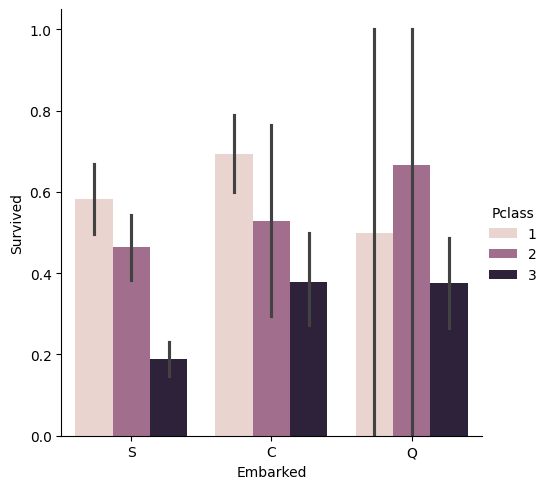

In [ ]:
sns.catplot(x='Embarked', y='Survived', hue='Pclass', kind='bar', data=df)